In [12]:
#导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
#卷积神经网络的参数 Conv2D卷积 MaxPooling2D 池化
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Input
from tensorflow.keras.utils import to_categorical

In [14]:
#加载数据和预处理数据
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

In [15]:
x_train.shape

(60000, 28, 28)

0


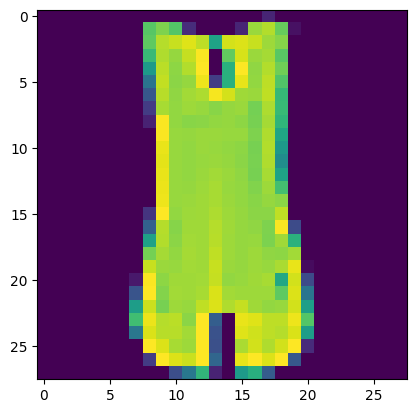

In [17]:
plt.imshow(x_train[4])
print(y_train[4])

In [18]:
# 预处理数据 标准化像素 /255.0 归一化到[0,1]之间
x_train = x_train / 255.0
x_test = x_test / 255.0

In [20]:
#卷积神经网络 对输入 有要求 需要增加一个维度 将(28,28) 转化为(28,28,1)
x_train = x_train.reshape(60000,28,28,1)
x_train.shape

(60000, 28, 28, 1)

In [21]:
#-1 表示 已有的数量
x_test = x_test.reshape(-1,28,28,1)
x_test.shape

(10000, 28, 28, 1)

In [22]:
#每个图片都有了一个颜色通道 1表示灰度通道 单通道
# 3 彩色通道 三通道(red green blue)

In [23]:
#输出应该是几个分类？ fashion mnist 有几个类别呀? 10
# 将标签 转化为 one-hot 编码格式
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [24]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [27]:
#构建卷积神经网络模型
model = Sequential([
    #指定单个图像的宽度 高度 通道
    Input(shape=(28,28,1)),
    #卷积操作
    #1.卷积层 给出多少个数量的卷积核 一般来说 32 64 128 256...
    Conv2D(32,(3,3),activation='relu'),
    #2.最大池化层
    MaxPooling2D((2,2)),
    
    #叠加卷积核
    Conv2D(64,(3,3),activation='relu'),
    #再池化
    MaxPooling2D((2,2)),

    #再叠加卷积核
    Conv2D(128,(3,3),activation='relu'),
    #池化
    MaxPooling2D((2,2)),

    #将三维数据展平为一维数据
    Flatten(),

    #全连接层
    Dense(512,activation='relu'),

    #输出层 sigmoid 二分类 softmax 多分类
    Dense(10,activation='softmax')
])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,850 (640.04 KB)

 Trainable params: 163,850 (640.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# 下一步: 编译模型
model.compile(
    optimizer='adam',
    # categorical_crossentropy
    loss='categorical_crossentropy',
    metrics=['accuracy'] #评估使用准确率
)

In [30]:
#下一步: 训练模型
model.fit(
    x_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7654 - loss: 0.6318 - val_accuracy: 0.8246 - val_loss: 0.4690
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8469 - loss: 0.4159 - val_accuracy: 0.8534 - val_loss: 0.3948
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.8677 - loss: 0.3564 - val_accuracy: 0.8673 - val_loss: 0.3631
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8845 - loss: 0.3114 - val_accuracy: 0.8769 - val_loss: 0.3294
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8939 - loss: 0.2829 - val_accuracy: 0.8798 - val_loss: 0.3296
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9050 - loss: 0.2549 - val_accuracy: 0.8870 - val_loss: 0.3046
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9125 - loss: 0.2352 - val_accuracy: 0.8834 - val_loss: 0.3241
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9194 - loss: 0.2152 - 

In [31]:
# 下一步：评估模型
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8952 - loss: 0.3149


[0.3148585259914398, 0.8952000141143799]

In [32]:
#进行预测
prediction = model.predict(x_test)
prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[9.2697249e-08, 5.1212492e-08, 3.0631486e-10, ..., 2.0774447e-04,
        1.2942182e-07, 9.9979085e-01],
       [1.3189184e-04, 3.0572895e-09, 9.9836165e-01, ..., 1.0796925e-11,
        7.6434873e-08, 1.2542682e-10],
       [5.0758822e-15, 1.0000000e+00, 8.6557983e-12, ..., 2.0944592e-24,
        1.0779063e-14, 1.4232688e-20],
       ...,
       [2.6287113e-11, 7.4351773e-14, 1.7752603e-13, ..., 2.6143879e-13,
        1.0000000e+00, 1.1567742e-12],
       [1.0310373e-11, 1.0000000e+00, 3.2553957e-10, ..., 3.9340518e-17,
        8.1847655e-14, 7.3554850e-13],
       [1.3361812e-05, 8.1582350e-08, 4.2010799e-07, ..., 1.8851789e-02,
        4.3413313e-03, 7.0132694e-04]], dtype=float32)

In [33]:
np.argmax(prediction[2])

1

In [34]:
#保存一下模型 新知识
model.save('mnist_model.keras')

In [35]:
#使用一下训练好的模型 来进行预测
import tensorflow as tf
new_model = tf.keras.models.load_model('mnist_model.keras')

In [37]:
#使用测试集的一些数据来进行预测
x_sample = x_test[:10]
y_sample = y_test[:10]

In [38]:
#模型预测
new_prediction = new_model.predict(x_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


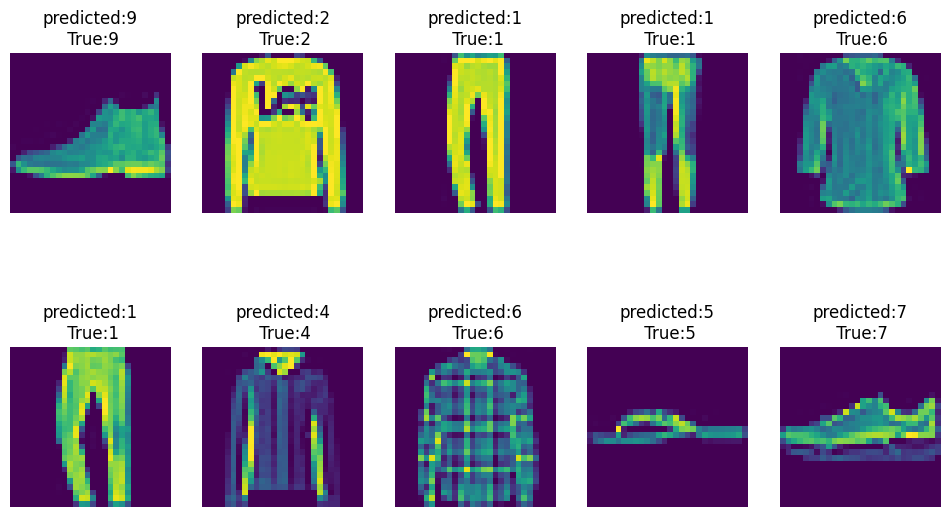

In [42]:
#可视化 每张图片 以及预测结果
plt.figure(figsize=(12,7))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_sample[i])
    plt.title(f'predicted:{np.argmax(new_prediction[i])}\n True:{np.argmax(y_sample[i])}')
    plt.axis('off')